In [9]:
import sys
!{sys.executable} -m pip install ipywidgets


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import keras
from keras import layers

import io
import imageio
from IPython.display import Image, display
from ipywidgets import widgets, Layout, HBox


In [5]:
import sys
!{sys.executable} -m pip install opencv-python


   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 1.7 MB/s eta 0:00:24
   - -------------------------------------- 1.0/40.2 MB 1.9 MB/s eta 0:00:21
   - -------------------------------------- 1.6/40.2 MB 2.2 MB/s eta 0:00:18
   - -------------------------------------- 1.8/40.2 MB 2.1 MB/s eta 0:00:18
   - -------------------------------------- 1.8/40.2 MB 2.1 MB/s eta 0:00:18
   -- ------------------------------------- 2.4/40.2 MB 1.7 MB/s eta 0:00:23
   -- ------------------------------------- 2.9/40.2 MB 1.8 MB/s eta 0:00:21
   -- ------------------------------------- 2.9/40.2 MB 1.8 MB/s eta 0:00:21
   --- ------------------------------------ 3.7/40.2 MB 1.8 MB/s eta 0:00:21
   --- ------------------------------------ 3.9/40.2 MB 1.8 MB/s eta 0:00:21
   --- -------------

تعداد ستون‌های زمانی شناسایی شده: 86
محدوده داده‌های نرمال‌شده: -1.0 تا 0.20209477229732847
ابعاد مکعب داده نهایی: (86, 128, 128)


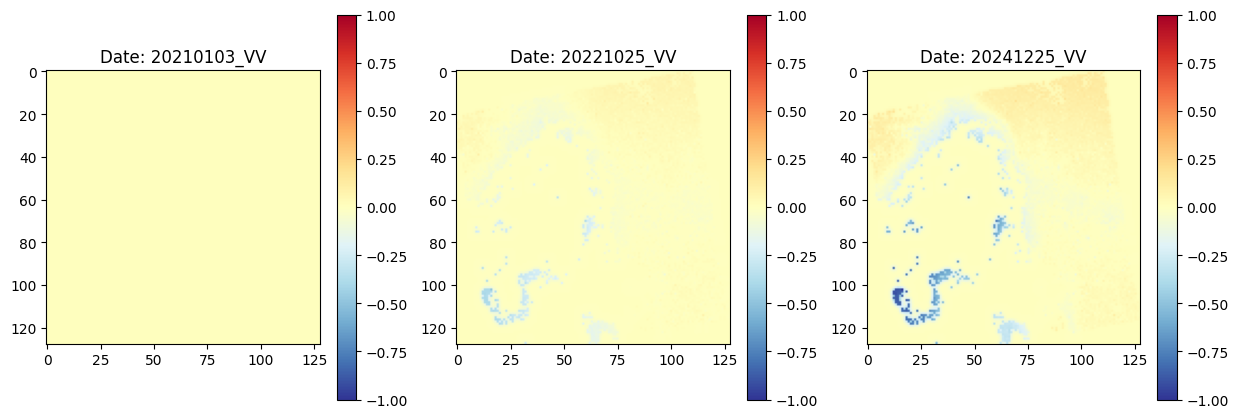

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv_lstm2d_8 (ConvLSTM2D)           │ (None, 5, 128, 128, 64)     │         150,016 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 5, 128, 128, 64)     │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 5, 128, 128, 64)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_9 (ConvLSTM2D)           │ (None, 128, 128, 32)        │         110,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 128, 128, 1)         │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 261,409 (1021.13 KB)

 Trainable params: 261,217 (1020.38 KB)

 Non-trainable params: 192 (768.00 B)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Dropout, Conv2D, Input

# ======================================================
# 1. خواندن فایل
# ======================================================
file_path = r'C:/convlstm/resultnahaei.csv'
df = pd.read_csv(file_path)

# انتخاب ستون‌های زمانی و مرتب‌سازی بر اساس تاریخ
time_cols = [c for c in df.columns if c.endswith('_VV') and not c.endswith('.1')]
time_cols = sorted(time_cols, key=lambda x: int(x.split('_')[0]))

print(f"تعداد ستون‌های زمانی شناسایی شده: {len(time_cols)}")

# ======================================================
# 2. نرمال‌سازی داده‌ها (حفظ مقادیر منفی برای نشست)
# ======================================================
values = df[time_cols].astype(float).values
values = np.nan_to_num(values, nan=0.0)

# نرمال‌سازی در بازه [-1, 1] بر اساس بیشترین قدرمطلق
max_abs = np.max(np.abs(values))
if max_abs != 0:
    values_norm = values / max_abs
else:
    values_norm = values

print("محدوده داده‌های نرمال‌شده:", values_norm.min(), "تا", values_norm.max())

# ======================================================
# 3. تبدیل به Grid (روش Binning)
# ======================================================
GRID_SIZE = 128
lon = df["LON"].astype(float).values
lat = df["LAT"].astype(float).values

def create_grid_from_points(lon, lat, values, grid_size):
    n_points, n_times = values.shape
    cube = np.zeros((n_times, grid_size, grid_size), dtype=np.float32)

    lon_min, lon_max = lon.min(), lon.max()
    lat_min, lat_max = lat.min(), lat.max()

    ix = ((lon - lon_min) / (lon_max - lon_min) * (grid_size - 1)).astype(int)
    iy = ((lat - lat_min) / (lat_max - lat_min) * (grid_size - 1)).astype(int)
    iy = (grid_size - 1) - iy # معکوس کردن Y

    for t in range(n_times):
        grid = np.zeros((grid_size, grid_size), dtype=np.float32)
        counts = np.zeros((grid_size, grid_size), dtype=np.int32)
        
        for i in range(n_points):
            grid[iy[i], ix[i]] += values[i, t]
            counts[iy[i], ix[i]] += 1
            
        grid = np.divide(grid, counts, out=np.zeros_like(grid), where=counts != 0)
        
        # پر کردن حفره‌ها
        if np.any(counts == 0):
            filled = gaussian_filter(grid, sigma=1)
            grid[counts == 0] = filled[counts == 0]
        cube[t] = grid
    return cube

frames = create_grid_from_points(lon, lat, values_norm, GRID_SIZE)
print("ابعاد مکعب داده نهایی:", frames.shape)

# ======================================================
# 4. نمایش (تأیید صحت داده‌ها)
# ======================================================
plt.figure(figsize=(15, 5))
# انتخاب فریم اول، وسطی و آخر
indices = [0, len(frames)//2, -1] 
for i, idx in enumerate(indices):
    plt.subplot(1, 3, i + 1)
    im = plt.imshow(frames[idx], cmap='RdYlBu_r', vmin=-1, vmax=1)
    plt.title(f"Date: {time_cols[idx]}")
    plt.colorbar(im)
plt.show()

# ======================================================
# 5. تعریف مدل ConvLSTM
# ======================================================
TIME_STEPS = 5 # تعداد فریم‌های ورودی
model = Sequential([
    Input(shape=(TIME_STEPS, GRID_SIZE, GRID_SIZE, 1)),
    ConvLSTM2D(filters=64, kernel_size=(3, 3), padding="same", return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),
    ConvLSTM2D(filters=32, kernel_size=(3, 3), padding="same", return_sequences=False),
    BatchNormalization(),
    Conv2D(filters=1, kernel_size=(3, 3), activation='tanh', padding='same')
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


In [13]:
# ======================================================
# 6. ساخت پنجره‌های لغزان (Sliding Windows) برای آموزش
# ======================================================
def create_sequences(data, time_steps=5):
    X, Y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps)])
        Y.append(data[i + time_steps])
    return np.array(X), np.array(Y)

# استفاده از کل مکعب (frames با ابعاد 86, 128, 128)
# تنظیم ابعاد برای مدل (نمونه‌ها، زمان، ارتفاع، عرض، کانال)
data_reshaped = frames.reshape(86, 128, 128, 1)

X, Y = create_sequences(data_reshaped, time_steps=5)

print(f"ابعاد داده‌های ورودی (X): {X.shape}") # باید (81, 5, 128, 128, 1) باشد
print(f"ابعاد داده‌های هدف (Y): {Y.shape}")   # باید (81, 128, 128, 1) باشد

# ======================================================
# 7. آموزش مدل
# ======================================================
# تقسیم به آموزش و تست (مثلاً 80 درصد آموزش)
split = int(0.8 * X.shape[0])
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

print("در حال شروع آموزش مدل...")
history = model.fit(
    X_train, Y_train,
    epochs=80,
    batch_size=4,
    validation_data=(X_test, Y_test),
    verbose=1
)

print("آموزش به پایان رسید!")

#



ابعاد داده‌های ورودی (X): (81, 5, 128, 128, 1)
ابعاد داده‌های هدف (Y): (81, 128, 128, 1)
در حال شروع آموزش مدل...
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - loss: 0.1221 - mae: 0.2350 - val_loss: 0.0076 - val_mae: 0.0548
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - loss: 0.0263 - mae: 0.0942 - val_loss: 0.0073 - val_mae: 0.0417
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - loss: 0.0103 - mae: 0.0561 - val_loss: 0.0074 - val_mae: 0.0388
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - loss: 0.0058 - mae: 0.0424 - val_loss: 0.0074 - val_mae: 0.0404
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - loss: 0.0040 - mae: 0.0360 - val_loss: 0.0073 - val_mae: 0.0391
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - loss: 0.0028 - mae: 0.0308 - val_loss: 0.0076 - val_mae: 0.0398
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - loss: 0.0024 - mae: 0.0288 - val_loss: 0.0080 - val_mae: 0.0407
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - loss: 0.0020 - mae: 0.

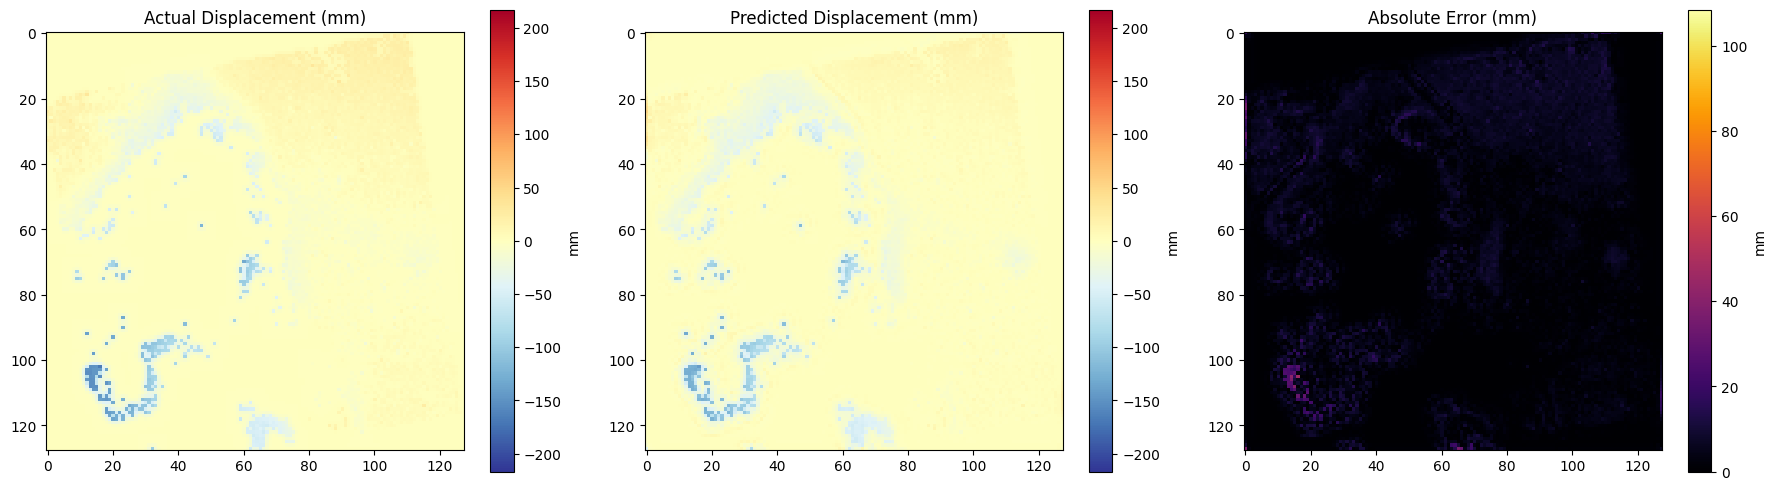

Mean Absolute Error (MAE): 3.2386 mm


In [16]:
# ======================================================
# 9. تبدیل نتایج به واحد اصلی (میلی‌متر) و نمایش
# ======================================================

# فرض بر این است که متغیر max_abs از مراحل قبل در حافظه موجود است
# اگر نیست، می‌توانید آن را به صورت دستی وارد کنید (مثلاً: max_abs = 25.4)

# 1. تبدیل پیش‌بینی‌ها و مقادیر واقعی به مقیاس اصلی
predictions_mm = test_predictions * max_abs
actual_mm = Y_test * max_abs

# 2. محاسبه خطا به میلی‌متر
error_mm = np.abs(actual_mm - predictions_mm)

# 3. انتخاب یک نمونه برای نمایش
idx = 0 
plt.figure(figsize=(18, 5))

# تنظیمات رنگ برای مقیاس واقعی (مثلاً بین 30- تا 30+ میلی‌متر)
limit = np.max(np.abs(actual_mm))

# تصویر واقعی (میلی‌متر)
plt.subplot(1, 3, 1)
plt.imshow(actual_mm[idx, :, :, 0], cmap='RdYlBu_r', vmin=-limit, vmax=limit)
plt.title("Actual Displacement (mm)")
plt.colorbar(label='mm')

# پیش‌بینی مدل (میلی‌متر)
plt.subplot(1, 3, 2)
plt.imshow(predictions_mm[idx, :, :, 0], cmap='RdYlBu_r', vmin=-limit, vmax=limit)
plt.title("Predicted Displacement (mm)")
plt.colorbar(label='mm')

# نقشه خطا (میلی‌متر)
plt.subplot(1, 3, 3)
plt.imshow(error_mm[idx, :, :, 0], cmap='inferno', vmin=0, vmax=limit/2)
plt.title("Absolute Error (mm)")
plt.colorbar(label='mm')

plt.tight_layout()
plt.show()

# چاپ میانگین خطا به میلی‌متر برای گزارش
print(f"Mean Absolute Error (MAE): {np.mean(error_mm):.4f} mm")



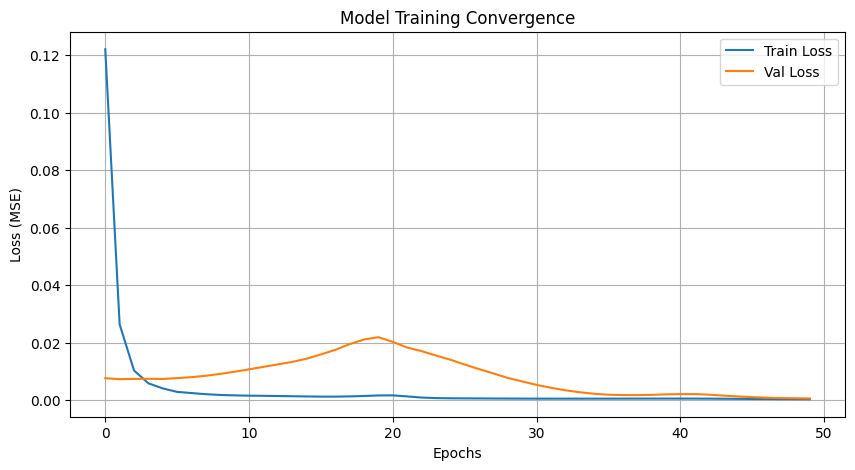

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


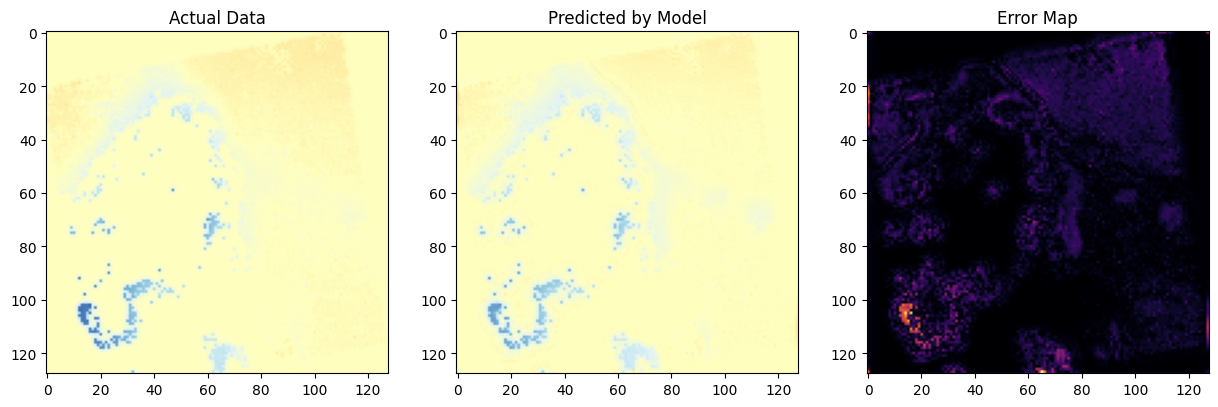

In [17]:
# 1. رسم نمودار Loss برای گزارش
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Training Convergence')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# 2. نمایش پیش‌بینی (همان کدی که در پیام قبلی دادم)
# این کد مقایسه نهایی است که باید در مقاله/گزارش بیاورید
test_predictions = model.predict(X_test)
idx = 5 # یک نمونه تصادفی از داده‌های تست
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(Y_test[idx, :, :, 0], cmap='RdYlBu_r', vmin=-1, vmax=1); plt.title("Actual Data")
plt.subplot(1, 3, 2); plt.imshow(test_predictions[idx, :, :, 0], cmap='RdYlBu_r', vmin=-1, vmax=1); plt.title("Predicted by Model")
plt.subplot(1, 3, 3); plt.imshow(np.abs(Y_test[idx, :, :, 0] - test_predictions[idx, :, :, 0]), cmap='inferno'); plt.title("Error Map")
plt.show()


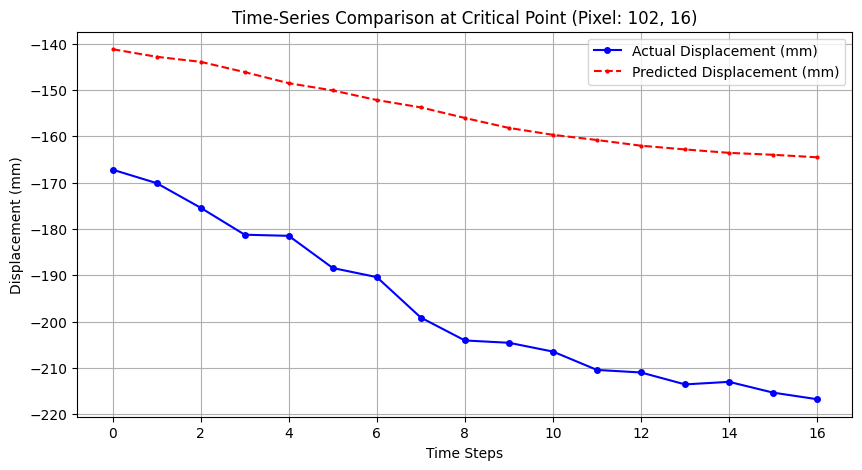

In [18]:
# ======================================================
# 10. رسم سری زمانی برای نقاط بحرانی (مقایسه دقت مدل)
# ======================================================

# یافتن پیکسلی که بیشترین نشست واقعی را داشته (بحرانی‌ترین نقطه)
# برای این کار میانگین زمانی تمام فریم‌های واقعی را در نظر می‌گیریم
mean_actual = np.mean(actual_mm, axis=(0, 3)) # میانگین در طول زمان و کانال
y_idx, x_idx = np.unravel_index(np.argmin(mean_actual), mean_actual.shape)

# استخراج سری زمانی برای این پیکسل خاص
time_series_actual = actual_mm[:, y_idx, x_idx, 0]
time_series_pred = predictions_mm[:, y_idx, x_idx, 0]

# رسم نمودار
plt.figure(figsize=(10, 5))
plt.plot(time_series_actual, 'bo-', label='Actual Displacement (mm)', markersize=4)
plt.plot(time_series_pred, 'r.--', label='Predicted Displacement (mm)', markersize=4)
plt.title(f"Time-Series Comparison at Critical Point (Pixel: {y_idx}, {x_idx})")
plt.xlabel("Time Steps")
plt.ylabel("Displacement (mm)")
plt.legend()
plt.grid(True)
plt.show()


In [19]:
# ======================================================
# 11. ذخیره نتایج پیش‌بینی در فایل CSV
# ======================================================

# تبدیل داده‌های پیش‌بینی (n_samples, grid, grid, 1) به فرمت قابل ذخیره
# ما میانگین پیش‌بینی‌ها را به ازای هر پیکسل در طول بازه تست می‌گیریم 
# یا می‌توانیم نتایجِ تست را به صورت یک ماتریس تخت (Flatten) ذخیره کنیم.

# در اینجا هر سطر CSV را یک پیکسل و ستون‌ها را زمان‌های پیش‌بینی شده قرار می‌دهیم:
num_samples = predictions_mm.shape[0]
grid_h = predictions_mm.shape[1]
grid_w = predictions_mm.shape[2]

# تبدیل به فرمت: (تعداد کل پیکسل‌ها، تعداد زمان‌ها)
# توجه: این کار حجم داده را بسیار زیاد می‌کند، پس فقط برای داده‌های تست ذخیره می‌کنیم
data_to_save = predictions_mm.reshape(num_samples, -1) # (Samples, Pixels)

df_results = pd.DataFrame(data_to_save)
output_path = r'C:/convlstm/predictions_test_results.csv'
df_results.to_csv(output_path, index=False)

print(f"نتایج با موفقیت در مسیر زیر ذخیره شد:\n{output_path}")
print(f"ابعاد فایل ذخیره شده: {df_results.shape}")


نتایج با موفقیت در مسیر زیر ذخیره شد:
C:/convlstm/predictions_test_results.csv
ابعاد فایل ذخیره شده: (17, 16384)


In [20]:
# محاسبه معیارهای آماری برای اثبات اعتبار (Validation Metrics)
mse = np.mean((Y_test - test_predictions) ** 2)
mae = np.mean(np.abs(Y_test - test_predictions))
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.4f} mm")
print(f"Root Mean Square Error (RMSE): {rmse:.4f} mm")
# محاسبه ضریب همبستگی R-squared
from sklearn.metrics import r2_score
r2 = r2_score(Y_test.flatten(), test_predictions.flatten())
print(f"R-squared Score: {r2:.4f}")


Mean Absolute Error (MAE): 0.0149 mm
Root Mean Square Error (RMSE): 0.0239 mm
R-squared Score: 0.9199


In [32]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from scipy import stats

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    ConvLSTM2D,
    BatchNormalization,
    Dropout,
    Conv2D
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam


# ============================================================
# 1. تنظیمات اصلی
# ============================================================

CSV_PATH = r"C:/convlstm/resultnahaei.csv"
OUTPUT_DIR = r"C:/convlstm/convlstm_outputs"

GRID_SIZE = 128
INPUT_STEPS = 5
PREDICT_STEPS = 1

TEST_RATIO = 0.15
VAL_RATIO = 0.15

EPOCHS = 80
BATCH_SIZE = 4
LEARNING_RATE = 1e-3

GAUSSIAN_SIGMA = 1.0

RANDOM_SEED = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


# ============================================================
# 2. توابع کمکی
# ============================================================

def find_time_columns(df):
    """
    انتخاب ستون‌های زمانی اصلی SARPROZ.
    ستون‌هایی مثل 20210103_VV انتخاب می‌شوند.
    ستون‌های تکراری مثل 20210103_VV.1 حذف می‌شوند.
    """
    time_cols = []
    for col in df.columns:
        col_str = str(col)
        if col_str.endswith("_VV") and not col_str.endswith(".1"):
            prefix = col_str.split("_")[0]
            if prefix.isdigit() and len(prefix) == 8:
                time_cols.append(col_str)

    time_cols = sorted(time_cols)
    return time_cols


def grid_points_to_cube(df, time_cols, grid_size=128, sigma=1.0):
    """
    تبدیل داده نقطه‌ای SARPROZ به مکعب زمانی-مکانی:
    خروجی: cube با شکل T x H x W
    """
    lat = df["LAT"].values
    lon = df["LON"].values

    lat_min, lat_max = lat.min(), lat.max()
    lon_min, lon_max = lon.min(), lon.max()

    row_idx = ((lat - lat_min) / (lat_max - lat_min) * (grid_size - 1)).astype(int)
    col_idx = ((lon - lon_min) / (lon_max - lon_min) * (grid_size - 1)).astype(int)

    # برعکس کردن محور latitude برای نمایش نقشه‌ای بهتر
    row_idx = grid_size - 1 - row_idx

    T = len(time_cols)
    cube = np.zeros((T, grid_size, grid_size), dtype=np.float32)
    count = np.zeros((grid_size, grid_size), dtype=np.float32)

    for t, col in enumerate(time_cols):
        values = df[col].values.astype(np.float32)

        grid_sum = np.zeros((grid_size, grid_size), dtype=np.float32)
        grid_count = np.zeros((grid_size, grid_size), dtype=np.float32)

        for r, c, v in zip(row_idx, col_idx, values):
            if not np.isnan(v):
                grid_sum[r, c] += v
                grid_count[r, c] += 1

        valid = grid_count > 0
        grid = np.zeros((grid_size, grid_size), dtype=np.float32)
        grid[valid] = grid_sum[valid] / grid_count[valid]

        # پرکردن نرم نقاط خالی با Gaussian smoothing
        mask = valid.astype(np.float32)
        smooth_grid = gaussian_filter(grid, sigma=sigma)
        smooth_mask = gaussian_filter(mask, sigma=sigma)

        filled_grid = np.zeros_like(grid)
        nonzero_mask = smooth_mask > 1e-6
        filled_grid[nonzero_mask] = smooth_grid[nonzero_mask] / smooth_mask[nonzero_mask]

        cube[t] = filled_grid

    geo_info = {
        "lat_min": float(lat_min),
        "lat_max": float(lat_max),
        "lon_min": float(lon_min),
        "lon_max": float(lon_max),
        "grid_size": grid_size
    }

    return cube, geo_info


def normalize_cube(cube):
    """
    نرمال‌سازی متقارن برای حفظ مقدارهای منفی و مثبت.
    خروجی در بازه تقریبی [-1, 1].
    """
    max_abs = np.nanmax(np.abs(cube))
    cube_norm = cube / max_abs
    return cube_norm.astype(np.float32), float(max_abs)


def create_sequences(cube_norm, input_steps=5, predict_steps=1):
    """
    ساخت دنباله‌های ConvLSTM.
    X shape: samples x time x H x W x channels
    Y shape: samples x H x W x channels
    """
    X, Y = [], []

    total_t = cube_norm.shape[0]

    for i in range(total_t - input_steps - predict_steps + 1):
        x_seq = cube_norm[i:i + input_steps]
        y_seq = cube_norm[i + input_steps + predict_steps - 1]

        X.append(x_seq)
        Y.append(y_seq)

    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32)

    X = X[..., np.newaxis]
    Y = Y[..., np.newaxis]

    return X, Y


def temporal_train_val_test_split(X, Y, val_ratio=0.15, test_ratio=0.15):
    """
    تقسیم زمانی داده‌ها.
    برای سری زمانی بهتر است shuffle انجام نشود.
    """
    n = X.shape[0]

    test_size = int(n * test_ratio)
    val_size = int(n * val_ratio)
    train_size = n - val_size - test_size

    X_train = X[:train_size]
    Y_train = Y[:train_size]

    X_val = X[train_size:train_size + val_size]
    Y_val = Y[train_size:train_size + val_size]

    X_test = X[train_size + val_size:]
    Y_test = Y[train_size + val_size:]

    return X_train, Y_train, X_val, Y_val, X_test, Y_test


def build_convlstm_model(input_shape):
    """
    مدل ConvLSTM برای پیش‌بینی نقشه تغییرشکل آینده.
    """
    model = Sequential([
        Input(shape=input_shape),

        ConvLSTM2D(
            filters=32,
            kernel_size=(3, 3),
            padding="same",
            return_sequences=True,
            activation="tanh"
        ),
        BatchNormalization(),
        Dropout(0.20),

        ConvLSTM2D(
            filters=16,
            kernel_size=(3, 3),
            padding="same",
            return_sequences=False,
            activation="tanh"
        ),
        BatchNormalization(),
        Dropout(0.20),

        Conv2D(
            filters=16,
            kernel_size=(3, 3),
            padding="same",
            activation="relu"
        ),

        Conv2D(
            filters=1,
            kernel_size=(1, 1),
            padding="same",
            activation="linear"
        )
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="mse",
        metrics=["mae"]
    )

    return model


def calculate_metrics(y_true, y_pred):
    """
    محاسبه معیارهای استاندارد مقاله.
    """
    true_flat = y_true.flatten()
    pred_flat = y_pred.flatten()

    mask = np.isfinite(true_flat) & np.isfinite(pred_flat)
    true_flat = true_flat[mask]
    pred_flat = pred_flat[mask]

    error = pred_flat - true_flat

    mae = mean_absolute_error(true_flat, pred_flat)
    mse = mean_squared_error(true_flat, pred_flat)
    rmse = np.sqrt(mse)
    r2 = r2_score(true_flat, pred_flat)

    pearson_r, pearson_p = stats.pearsonr(true_flat, pred_flat)

    bias = np.mean(error)
    std_error = np.std(error)

    median_abs_error = np.median(np.abs(error))
    p50_abs_error = np.percentile(np.abs(error), 50)
    p75_abs_error = np.percentile(np.abs(error), 75)
    p90_abs_error = np.percentile(np.abs(error), 90)
    p95_abs_error = np.percentile(np.abs(error), 95)

    # MAPE فقط برای جاهایی که مقدار واقعی نزدیک صفر نیست
    nonzero_mask = np.abs(true_flat) > 1e-6
    if np.sum(nonzero_mask) > 0:
        mape = np.mean(
            np.abs((true_flat[nonzero_mask] - pred_flat[nonzero_mask]) / true_flat[nonzero_mask])
        ) * 100
    else:
        mape = np.nan

    metrics = {
        "MAE_mm": mae,
        "MSE_mm2": mse,
        "RMSE_mm": rmse,
        "R2": r2,
        "Pearson_r": pearson_r,
        "Pearson_p_value": pearson_p,
        "Bias_Mean_Error_mm": bias,
        "Std_Error_mm": std_error,
        "Median_Absolute_Error_mm": median_abs_error,
        "P50_Absolute_Error_mm": p50_abs_error,
        "P75_Absolute_Error_mm": p75_abs_error,
        "P90_Absolute_Error_mm": p90_abs_error,
        "P95_Absolute_Error_mm": p95_abs_error,
        "MAPE_percent": mape
    }

    return metrics


# ============================================================
# 3. خواندن داده SARPROZ
# ============================================================

print("Reading SARPROZ CSV file...")
df = pd.read_csv(CSV_PATH)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

time_cols = find_time_columns(df)

print("Number of selected time-series columns:", len(time_cols))
print("First date:", time_cols[0])
print("Last date:", time_cols[-1])

if len(time_cols) < INPUT_STEPS + PREDICT_STEPS + 3:
    raise ValueError("Not enough time-series columns for ConvLSTM sequence generation.")


# ============================================================
# 4. تبدیل نقطه‌ها به مکعب مکانی-زمانی
# ============================================================

print("Creating spatio-temporal cube...")
cube_mm, geo_info = grid_points_to_cube(
    df=df,
    time_cols=time_cols,
    grid_size=GRID_SIZE,
    sigma=GAUSSIAN_SIGMA
)

print("Cube shape T x H x W:", cube_mm.shape)

with open(os.path.join(OUTPUT_DIR, "geo_info.json"), "w") as f:
    json.dump(geo_info, f, indent=4)


# ============================================================
# 5. نرمال‌سازی
# ============================================================

cube_norm, scale_factor_mm = normalize_cube(cube_mm)

print("Scale factor mm:", scale_factor_mm)

with open(os.path.join(OUTPUT_DIR, "normalization_info.json"), "w") as f:
    json.dump({"scale_factor_mm": scale_factor_mm}, f, indent=4)


# ============================================================
# 6. ساخت دنباله‌ها
# ============================================================

X, Y = create_sequences(
    cube_norm=cube_norm,
    input_steps=INPUT_STEPS,
    predict_steps=PREDICT_STEPS
)

print("X shape:", X.shape)
print("Y shape:", Y.shape)


# ============================================================
# 7. تقسیم آموزش، اعتبارسنجی و تست
# ============================================================

X_train, Y_train, X_val, Y_val, X_test, Y_test = temporal_train_val_test_split(
    X,
    Y,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO
)

print("Train:", X_train.shape, Y_train.shape)
print("Validation:", X_val.shape, Y_val.shape)
print("Test:", X_test.shape, Y_test.shape)


# ============================================================
# 8. ساخت و آموزش مدل
# ============================================================

model = build_convlstm_model(input_shape=X_train.shape[1:])
model.summary()

with open(os.path.join(OUTPUT_DIR, "model_summary.txt"), "w", encoding="utf-8") as f:
    model.summary(print_fn=lambda x: f.write(x + "\n"))

checkpoint_path = os.path.join(OUTPUT_DIR, "best_convlstm_model.keras")

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=6,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True
    )
]

print("Training model...")
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

model.save(os.path.join(OUTPUT_DIR, "final_convlstm_model.keras"))


# ============================================================
# 9. ذخیره تاریخچه آموزش
# ============================================================

history_df = pd.DataFrame(history.history)
history_df.to_csv(os.path.join(OUTPUT_DIR, "training_history.csv"), index=False)


# ============================================================
# 10. پیش‌بینی روی داده تست
# ============================================================

print("Predicting test data...")
Y_pred_norm = model.predict(X_test)

Y_test_mm = Y_test * scale_factor_mm
Y_pred_mm = Y_pred_norm * scale_factor_mm

error_mm = Y_pred_mm - Y_test_mm
abs_error_mm = np.abs(error_mm)


# ============================================================
# 11. محاسبه معیارهای مقاله
# ============================================================

metrics = calculate_metrics(Y_test_mm, Y_pred_mm)

metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(os.path.join(OUTPUT_DIR, "metrics_summary.csv"), index=False)

# تبدیل همه مقادیر numpy به float معمولی
def convert_numpy(obj):
    if isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    if isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    return obj

metrics_clean = {k: convert_numpy(v) for k, v in metrics.items()}

with open(os.path.join(OUTPUT_DIR, "metrics_summary.json"), "w") as f:
    json.dump(metrics_clean, f, indent=4)


print("\n================ METRICS ================")
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")
print("=========================================\n")


# ============================================================
# 12. ذخیره پیش‌بینی‌ها به صورت CSV
# ============================================================

results_df = pd.DataFrame({
    "actual_mm": Y_test_mm.flatten(),
    "predicted_mm": Y_pred_mm.flatten(),
    "error_mm": error_mm.flatten(),
    "absolute_error_mm": abs_error_mm.flatten()
})

results_df.to_csv(
    os.path.join(OUTPUT_DIR, "predictions_test_results.csv"),
    index=False
)


# ============================================================
# 13. نقشه واقعی، پیش‌بینی و خطا
# ============================================================

sample_idx = -1

actual_map = Y_test_mm[sample_idx, :, :, 0]
pred_map = Y_pred_mm[sample_idx, :, :, 0]
err_map = pred_map - actual_map

max_abs_disp = np.nanmax(np.abs([actual_map, pred_map]))
max_abs_err = np.nanmax(np.abs(err_map))

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(actual_map, cmap="RdYlBu_r", vmin=-max_abs_disp, vmax=max_abs_disp)
plt.title("Actual Displacement")
plt.colorbar(label="Displacement (mm)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(pred_map, cmap="RdYlBu_r", vmin=-max_abs_disp, vmax=max_abs_disp)
plt.title("Predicted Displacement")
plt.colorbar(label="Displacement (mm)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(err_map, cmap="seismic", vmin=-max_abs_err, vmax=max_abs_err)
plt.title("Prediction Error")
plt.colorbar(label="Error (mm)")
plt.axis("off")

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "fig_actual_predicted_error_map.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# ============================================================
# 14. نمودار Loss و MAE
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training and Validation MAE")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "fig_training_curves.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# ============================================================
# 15. Scatter plot: Actual vs Predicted
# ============================================================

actual_flat = Y_test_mm.flatten()
pred_flat = Y_pred_mm.flatten()

sample_size = min(100000, len(actual_flat))
sample_indices = np.random.choice(len(actual_flat), sample_size, replace=False)

actual_sample = actual_flat[sample_indices]
pred_sample = pred_flat[sample_indices]

min_val = min(actual_sample.min(), pred_sample.min())
max_val = max(actual_sample.max(), pred_sample.max())

plt.figure(figsize=(7, 7))
plt.scatter(actual_sample, pred_sample, s=2, alpha=0.25)
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)
plt.xlabel("Actual Displacement (mm)")
plt.ylabel("Predicted Displacement (mm)")
plt.title(
    f"Actual vs Predicted\n"
    f"R²={metrics['R2']:.4f}, RMSE={metrics['RMSE_mm']:.4f} mm"
)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "fig_scatter_actual_vs_predicted.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# ============================================================
# 16. Histogram of residuals
# ============================================================

residuals = error_mm.flatten()

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=80, color="steelblue", edgecolor="black", alpha=0.75)
plt.axvline(0, color="red", linestyle="--", linewidth=2)
plt.xlabel("Residual Error (mm)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Residuals")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "fig_residual_histogram.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# ============================================================
# 17. Q-Q plot برای بررسی نرمال بودن خطا
# ============================================================

plt.figure(figsize=(7, 7))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Prediction Residuals")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "fig_residual_qqplot.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# ============================================================
# 18. Boxplot of absolute errors
# ============================================================

plt.figure(figsize=(6, 6))
plt.boxplot(abs_error_mm.flatten(), vert=True, showfliers=False)
plt.ylabel("Absolute Error (mm)")
plt.title("Boxplot of Absolute Prediction Errors")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "fig_absolute_error_boxplot.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# ============================================================
# 19. نقشه میانگین خطا در کل تست
# ============================================================

mean_abs_error_map = np.mean(abs_error_mm[:, :, :, 0], axis=0)
mean_error_map = np.mean(error_mm[:, :, :, 0], axis=0)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(mean_abs_error_map, cmap="magma")
plt.title("Mean Absolute Error Map")
plt.colorbar(label="MAE (mm)")
plt.axis("off")

plt.subplot(1, 2, 2)
max_abs_mean_error = np.max(np.abs(mean_error_map))
plt.imshow(
    mean_error_map,
    cmap="seismic",
    vmin=-max_abs_mean_error,
    vmax=max_abs_mean_error
)
plt.title("Mean Error / Bias Map")
plt.colorbar(label="Mean Error (mm)")
plt.axis("off")

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "fig_spatial_error_statistics.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# ============================================================
# 20. سری زمانی در بحرانی‌ترین نقطه
# ============================================================

# نقطه‌ای که در کل تست بیشترین جابه‌جایی واقعی را دارد
mean_actual_abs = np.mean(np.abs(Y_test_mm[:, :, :, 0]), axis=0)
critical_row, critical_col = np.unravel_index(
    np.argmax(mean_actual_abs),
    mean_actual_abs.shape
)

actual_ts = Y_test_mm[:, critical_row, critical_col, 0]
pred_ts = Y_pred_mm[:, critical_row, critical_col, 0]

plt.figure(figsize=(9, 5))
plt.plot(actual_ts, marker="o", label="Actual")
plt.plot(pred_ts, marker="s", label="Predicted")
plt.xlabel("Test Time Step")
plt.ylabel("Displacement (mm)")
plt.title(
    f"Time-Series Comparison at Critical Pixel "
    f"({critical_row}, {critical_col})"
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "fig_timeseries_critical_pixel.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# ============================================================
# 21. ذخیره مکعب‌ها و خروجی‌های عددی مهم
# ============================================================

np.save(os.path.join(OUTPUT_DIR, "Y_test_mm.npy"), Y_test_mm)
np.save(os.path.join(OUTPUT_DIR, "Y_pred_mm.npy"), Y_pred_mm)
np.save(os.path.join(OUTPUT_DIR, "error_mm.npy"), error_mm)
np.save(os.path.join(OUTPUT_DIR, "cube_mm.npy"), cube_mm)

print("All outputs saved in:")
print(OUTPUT_DIR)


Reading SARPROZ CSV file...
Rows: 15203
Columns: 188
Number of selected time-series columns: 86
First date: 20210103_VV
Last date: 20241225_VV
Creating spatio-temporal cube...
Cube shape T x H x W: (86, 128, 128)
Scale factor mm: 208.58209228515625
X shape: (81, 5, 128, 128, 1)
Y shape: (81, 128, 128, 1)
Train: (57, 5, 128, 128, 1) (57, 128, 128, 1)
Validation: (12, 5, 128, 128, 1) (12, 128, 128, 1)
Test: (12, 5, 128, 128, 1) (12, 128, 128, 1)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv_lstm2d_12 (ConvLSTM2D)          │ (None, 5, 128, 128, 32)     │          38,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 5, 128, 128, 32)     │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 5, 128, 128, 32)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_13 (ConvLSTM2D)          │ (None, 128, 128, 16)        │          27,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 128, 128, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128, 128, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 128, 128, 16)        │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 128, 128, 1)         │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 68,385 (267.13 KB)

 Trainable params: 68,289 (266.75 KB)

 Non-trainable params: 96 (384.00 B)

Training model...
Epoch 1/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 643ms/step - loss: 0.1479 - mae: 0.2614 - val_loss: 0.0355 - val_mae: 0.1002 - learning_rate: 0.0010
Epoch 2/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 618ms/step - loss: 0.0781 - mae: 0.2016 - val_loss: 0.0356 - val_mae: 0.1012 - learning_rate: 0.0010
Epoch 3/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 623ms/step - loss: 0.0523 - mae: 0.1655 - val_loss: 0.0365 - val_mae: 0.1050 - learning_rate: 0.0010
Epoch 4/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 623ms/step - loss: 0.0362 - mae: 0.1388 - val_loss: 0.0350 - val_mae: 0.1069 - learning_rate: 0.0010
Epoch 5/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 625ms/step - loss: 0.0264 - mae: 0.1191 - val_loss: 0.0352 - val_mae: 0.1098 - learning_rate: 0.0010
Epoch 6/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 628ms/step - loss: 0.0199 - mae: 0.1035 - val_loss: 0.0353 - val_mae: 0.1149 - learning_rate: 0.0010
Epoch 7/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 624ms/step - loss: 0.0155 - mae: 0.0914 - val_loss: 0.0354 - val_mae: 0.1211 - learning_